In [2]:
import keras
from keras import layers
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from metrics_tracking import F1Score, plot_metrics

In [3]:
OTIDS_file_colab = "OTIDS_clean_data.npz"
OTIDS_file_local = "Preprocessed_Data/OTIDS_clean_data.npz"
data = np.load(OTIDS_file_local)
# Access arrays by the names you used when saving
X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]
y_train = y_train.astype("int32").ravel()
y_test  = y_test.astype("int32").ravel()

In [ ]:
def create_model_otids():
    inp = keras.Input(shape=(600, 11))
    x = layers.Conv1D(64, 12, activation='relu')(inp)
    x_max = layers.GlobalMaxPooling1D()(x)
    x_avg = layers.GlobalAveragePooling1D()(x)
    x = layers.Concatenate()([x_max, x_avg])
    x = layers.Dense(32, activation='relu')(x)   # optional small dense
    out = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inp, out)
    return model
model = create_model_otids()
#1d cnn sequential model:
# def create_model_otids(num_filters=128, kernel=8): #this is the same model we'll always use for all.
#     model = keras.Sequential()
#     model.add(layers.Input(shape=(600, 11)))
#     #model.add(layers.Conv1D(128, 8, activation='relu'))#64 was pretty decent
#     model.add(layers.Conv1D(num_filters, 8, activation='relu'))
#     # model.add(layers.GlobalMaxPooling1D())
#     model.add(layers.GlobalAveragePooling1D())
#     model.add(layers.Dense(1, activation='sigmoid')) #output 1 bc we only have 2 labels: attack or not attack
#     return model

# filters = 96 #128
# kernel_size = 16 #8
# model = create_model_otids(96, 16)

In [42]:
callbacks = [
    ModelCheckpoint("saved_models/best_model_OTIDS_128cnn.keras", monitor='val_auc', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, min_lr=1e-12, verbose=1),
    EarlyStopping(monitor='val_auc', patience=10, verbose=1, restore_best_weights=True)
]
model.compile(
    optimizer=keras.optimizers.Adam(5e-4),
    loss="binary_crossentropy",   # correct for sigmoid + 0/1 labels
    metrics=[
        keras.metrics.AUC(name="auc"),
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        F1Score(name="f1")
    ]
)
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=70,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/70
955/957 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5318 - auc: 0.5427 - f1: 0.5549 - loss: 0.6897 - precision: 0.5375 - recall: 0.5780
Epoch 1: val_auc improved from None to 0.76132, saving model to saved_models/best_model_OTIDS_128cnn.keras
957/957 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.5545 - auc: 0.5734 - f1: 0.5931 - loss: 0.6848 - precision: 0.5583 - recall: 0.6327 - val_accuracy: 0.5062 - val_auc: 0.7613 - val_f1: 0.0889 - val_loss: 0.6785 - val_precision: 0.9425 - val_recall: 0.0467 - learning_rate: 5.0000e-04
Epoch 2/70
956/957 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6352 - auc: 0.6985 - f1: 0.6597 - loss: 0.6536 - precision: 0.6351 - recall: 0.6947
Epoch 2: val_auc improved from 0.76132 to 0.79767, saving model to saved_models/best_model_OTIDS_128cnn.keras
957/957 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.6567 - auc: 0.7190 - f1: 0.6804 - loss: 0.6383 - precision: 0.6515 - recall: 0.7120 - val_accuracy: 0.7084 - val_auc: 0.7977 - val_f1

In [43]:
testing_acc = model.evaluate(X_test,y_test, verbose=1)
print(f"Test loss: {testing_acc[0]}")
print(f"Test accuracy: {testing_acc[1]}")
print(f"Test AUC: {testing_acc[2]}")
print(f"Test Precision: {testing_acc[3]}")
print(f"Test Recall: {testing_acc[4]}")
print(f"Test F1: {testing_acc[5]}")

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7865 - auc: 0.8695 - f1: 0.7819 - loss: 0.5257 - precision: 0.8224 - recall: 0.7452
Test loss: 0.5257185101509094
Test accuracy: 0.8695060014724731
Test AUC: 0.7864534258842468
Test Precision: 0.8223850727081299
Test Recall: 0.745192289352417
Test F1: 0.781887948513031


In [45]:
model.save("best_OTIDS_model128.keras")

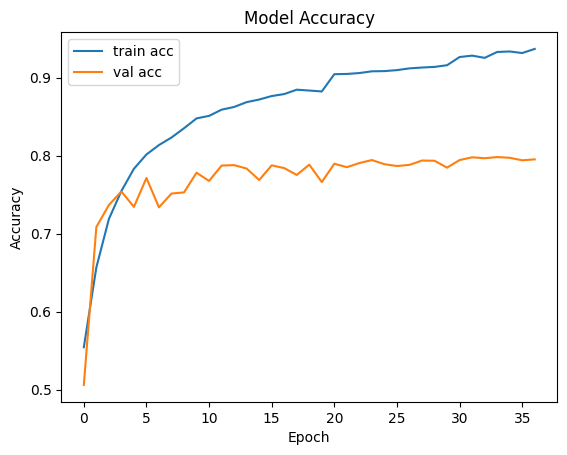

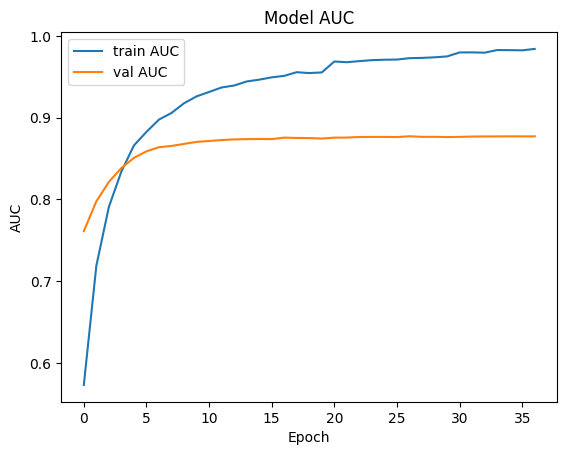

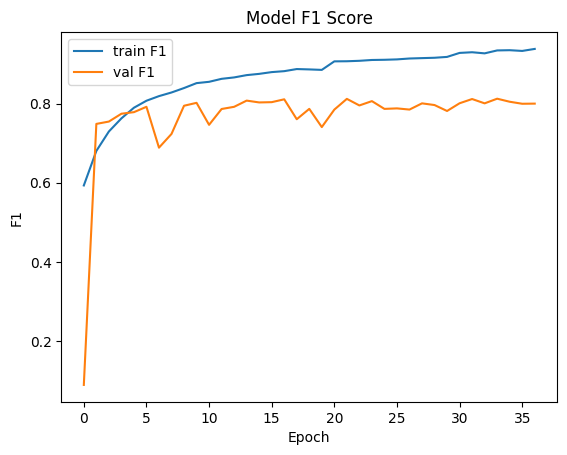

In [46]:
plot_metrics(history)

In [47]:
y_pred_probs = model.predict(X_test).ravel()     # shape: (N,)
y_pred = (y_pred_probs >= 0.5).astype(int)       # threshold

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred, target_names=["Ambient", "Attack"]))

# --- Correct ROC-AUC for binary classifier ---
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

     Ambient       0.76      0.83      0.79      4136
      Attack       0.82      0.75      0.78      4368

    accuracy                           0.79      8504
   macro avg       0.79      0.79      0.79      8504
weighted avg       0.79      0.79      0.79      8504

ROC AUC Score: 0.8700


In [ ]:
def standardize(X_train, y_train, X_test, y_test):
    # Step 1: Clip outliers (important for ROAD)
    X_train = np.clip(X_train, -1e6, 1e6)
    X_test  = np.clip(X_test,  -1e6, 1e6)
    # Step 2: Standardize features
    scaler = StandardScaler()
    X_train_flat = X_train.reshape(-1, X_train.shape[-1])
    X_test_flat  = X_test.reshape(-1,  X_test.shape[-1])
    X_train_scaled = scaler.fit_transform(X_train_flat)
    X_test_scaled  = scaler.transform(X_test_flat)
    X_train = X_train_scaled.reshape(X_train.shape)
    X_test  = X_test_scaled.reshape(X_test.shape)
    return X_train, y_train, X_test, y_test
X_train, y_train, X_test, y_test = standardize(X_train, y_train, X_test, y_test)

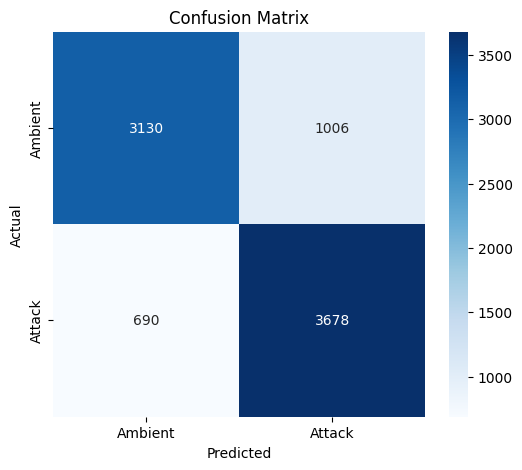

In [30]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Ambient", "Attack"],
    yticklabels=["Ambient", "Attack"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()